In [ ]:
!apt-get install libgeos-dev
!pip install https://github.com/matplotlib/basemap/archive/master.zip

Reading package lists... Done
Building dependency tree       
Reading state information... Done
libgeos-dev is already the newest version (3.6.2-1build2).
The following package was automatically installed and is no longer required:
  libnvidia-common-460
Use 'apt autoremove' to remove it.
0 upgraded, 0 newly installed, 0 to remove and 40 not upgraded.
  Using cached https://github.com/matplotlib/basemap/archive/master.zip


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap

from google.colab import drive, files

from google_trans_new import google_translator  

import os

In [ ]:
key_list = ["TL", "RF", "TP", "dd", "ff", "ffx", "P", "RR", "SH", "SO", "TS", "RRR", "RRS", "RRI", "VIS1", "VIS10", "WWa", "WW15", "WW60", "Qual_FD12P", "Stat_FD12P", "o1", "h1", "o2", "h2", "o3", "h3", "o4", "h4", "o5", "h5", "Alb_CL31", "Wab_CL31", "Stb_CL31", "DSt_CL31", "Stat_CL31", "RRM", "Metar", "Metar2", "ReMetar", "Pred", "Pgpm"]
desc_list = ['Air temperature', 'Relative humidity', 'Dew point temperature', 'Wind direction', 'Wind speed', 'Wind speed peak value', 'Air pressure', 'Precipitation balance', 'Snow depth SHM30', 'Sunshine duration', 'Ground temperature + 5cm', 'Total precipitation liquid PWS', 'Total precipitation snow PWS', 'Precipitation intensity PWS', 'Visibility mean value 1 minute PWS', 'Visibility mean value 10 minute PWS', 'Weather code instantaneous value PWS', 'Weather code 15 minute value PWS', 'Weather code 60 minute value PWS', 'Hardware-Error / Warning PWS', 'Status PWS', 'Degree of cloud layer 1', 'Height layer 1', 'Degree of cloud layer 2', 'High cloud layer 2', 'Cloud layer 3', 'Cloud layer 3', 'Cloud layer 4', 'Cloud layer 4', 'Cloud layer 5', 'Cloud layer 5', 'Alarm bits from sensor (32-47) CL31', 'Warning bits from sensor (16-31) CL31', 'Status bits from sensor (00-15) CL 31', 'Detection Status CL31', 'Status CL31', 'Precipitation detector', 'METAR WX-Code 1', 'METAR WX-Code 2', 'METAR REWX-Code', 'Reduced air pressure', 'Geopotential meter']
description_dict = {'TL': 'Air temperature', 'RF': 'Relative humidity', 'TP': 'Dew point temperature', 'dd': 'Wind direction', 'ff': 'Wind speed', 'ffx': 'Wind speed peak value', 'P': 'Air pressure', 'RR': 'Precipitation balance', 'SH': 'Snow depth SHM30', 'SO': 'Sunshine duration', 'TS': 'Ground temperature + 5cm', 'RRR': 'Total precipitation liquid PWS', 'RRS': 'Total precipitation snow PWS', 'RRI': 'Precipitation intensity PWS', 'VIS1': 'Visibility mean value 1 minute PWS', 'VIS10': 'Visibility mean value 10 minute PWS', 'WWa': 'Weather code instantaneous value PWS', 'WW15': 'Weather code 15 minute value PWS', 'WW60': 'Weather code 60 minute value PWS', 'Qual_FD12P': 'Hardware-Error / Warning PWS', 'Stat_FD12P': 'Status PWS', 'o1': 'Degree of cloud layer 1', 'h1': 'Height layer 1', 'o2': 'Degree of cloud layer 2', 'h2': 'High cloud layer 2', 'o3': 'Cloud layer 3', 'h3': 'Cloud layer 3', 'o4': 'Cloud layer 4', 'h4': 'Cloud layer 4', 'o5': 'Cloud layer 5', 'h5': 'Cloud layer 5', 'Alb_CL31': 'Alarm bits from sensor (32-47) CL31', 'Wab_CL31': 'Warning bits from sensor (16-31) CL31', 'Stb_CL31': 'Status bits from sensor (00-15) CL 31', 'DSt_CL31': 'Detection Status CL31', 'Stat_CL31': 'Status CL31', 'RRM': 'Precipitation detector', 'Metar': 'METAR WX-Code 1', 'Metar2': 'METAR WX-Code 2', 'ReMetar': 'METAR REWX-Code', 'Pred': 'Reduced air pressure', 'Pgpm': 'Geopotential meter'}


In [ ]:
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
TOTAL = 263088

In [ ]:
vis = np.load('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/vis_54.npy')
temp = np.load('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/t_54.npy')
dew = np.load('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/dt_54.npy')
prec = np.load('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/prec_54.npy')
ws = np.load('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/ws_54.npy')
wd = np.load('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/wd_54.npy')

In [ ]:
vis = wd

In [1]:
keys_list = ['11002', '11007', '11018', '11021', '11024', '11049', '11050', '11056', '11058', '11063', '11070', '11105', '11131', '11140', '11144', '11148', '11167', '11171', '11173', '11176', '11188', '11190', '11198', '11200', '11201', '11204', '11208', '11214', '11220', '11225', '11229', '11237', '11249', '11259', '11272', '11296', '11311', '11314', '11325', '11329', '11330', '11335', '11341', '11347', '11356', '11362', '11371', '11380', '11389', '11390', '11393', '11395', '89072', '11036']

lat_list = [48.1958, 48.6028, 48.1089, 48.9547, 48.3344, 48.0972, 48.4592, 48.0067, 48.3267, 47.5078, 48.4183, 47.2711, 47.6628, 47.5844, 47.29, 47.0944, 47.5944, 47.7892, 47.4442, 47.4583, 47.575, 47.8542, 47.0625, 47.0047, 46.7464, 46.8256, 47.38, 46.9381, 47.0697, 46.8492, 46.7642, 46.7392, 47.2556, 46.6097, 46.7906, 46.7675, 47.1314, 47.4944, 47.3889, 47.0983, 47.1625, 48.7314, 0.0, 47.8831, 47.6106, 47.4214, 47.5911, 47.6997, 48.1997, 47.2806, 47.4653, 47.77, 0.0, 48.1103]

lon_list = [14.4503, 13.8392, 14.895, 15.0383, 15.3392, 13.1511, 14.3456, 13.6456, 13.8647, 14.4303, 15.6214, 9.6097, 12.3939, 12.6953, 12.7864, 13.6228, 14.4908, 15.3022, 15.6439, 15.3356, 16.1014, 16.5383, 16.3219, 12.6464, 12.4236, 12.8064, 13.4408, 14.915, 14.4247, 14.1908, 14.8281, 14.3856, 15.315, 13.4922, 13.4872, 15.5528, 10.2667, 10.7153, 11.7581, 11.4661, 11.8514, 16.3897, 0.0, 14.1344, 13.7583, 14.7597, 13.1817, 15.8369, 15.6311, 15.9786, 16.6456, 17.0356, 0.0, 16.5697]

nan_count = [46016, 18379, 2017, 1754, 3729, 29090, 2289, 43894, 32730, 5433, 4624, 1565, 2446, 35678, 236959, 27735, 4013, 4382, 1822, 127476, 1104, 1700, 7007, 2482, 1872, 9449, 135629, 7974, 2167, 3393, 2956, 20207, 1580, 30487, 1352, 3381, 2369, 3542, 4188, 5467, 5189, 15375, 263088, 31883, 32151, 2994, 31581, 2134, 5392, 1758, 1420, 4804, 263088]

closest_list = [[0, 6, 43, 2, 8, 16, 9, 1, 7, 45, 4, 44, 17, 3, 28, 19, 48, 10, 32, 26, 5, 27, 29, 15, 46, 18, 31, 47, 30, 34, 20, 49, 35, 33, 13, 14, 41, 21, 53, 12, 25, 23, 22, 50, 24, 51, 40, 38, 39, 37, 36, 11, 42, 52], [1, 8, 6, 7, 0, 43, 5, 44, 2, 16, 46, 9, 3, 26, 45, 4, 15, 13, 28, 17, 14, 12, 29, 10, 48, 34, 19, 31, 27, 23, 32, 33, 25, 30, 18, 47, 24, 38, 40, 20, 35, 49, 41, 53, 21, 39, 22, 50, 51, 37, 36, 11, 52, 42], [2, 0, 4, 17, 6, 16, 45, 48, 9, 19, 10, 43, 3, 32, 18, 47, 8, 28, 1, 27, 44, 7, 20, 30, 49, 29, 31, 35, 41, 26, 15, 21, 53, 5, 22, 46, 50, 34, 33, 51, 13, 14, 25, 23, 12, 24, 40, 38, 39, 37, 36, 11, 52, 42], [3, 4, 10, 6, 2, 48, 0, 17, 1, 8, 41, 43, 16, 47, 19, 45, 9, 18, 7, 32, 20, 53, 44, 21, 49, 28, 27, 5, 50, 30, 26, 35, 29, 22, 46, 31, 51, 15, 34, 13, 14, 33, 12, 25, 23, 24, 38, 40, 39, 37, 36, 11, 42, 52], [4, 10, 48, 2, 17, 3, 47, 19, 0, 18, 6, 20, 32, 45, 41, 16, 9, 49, 53, 43, 21, 27, 8, 1, 28, 50, 35, 22, 30, 7, 44, 51, 31, 29, 15, 26, 5, 46, 34, 33, 13, 14, 25, 23, 12, 24, 40, 38, 39, 37, 36, 11, 42, 52], [5, 7, 46, 13, 8, 26, 44, 1, 12, 14, 43, 15, 23, 6, 0, 25, 34, 9, 16, 33, 24, 38, 40, 29, 28, 2, 45, 31, 39, 3, 27, 30, 17, 4, 19, 32, 48, 10, 37, 18, 47, 35, 49, 20, 36, 41, 22, 21, 53, 50, 11, 51, 42, 52], [6, 0, 8, 1, 43, 2, 7, 3, 16, 9, 4, 44, 45, 17, 5, 10, 48, 28, 19, 26, 46, 15, 32, 29, 27, 18, 47, 31, 30, 13, 34, 14, 20, 49, 33, 41, 35, 12, 23, 25, 53, 21, 22, 50, 24, 51, 38, 40, 39, 37, 36, 11, 42, 52], [7, 8, 44, 5, 43, 46, 1, 26, 0, 6, 15, 9, 16, 13, 14, 28, 34, 2, 45, 29, 12, 33, 23, 25, 31, 27, 17, 3, 30, 4, 24, 19, 32, 40, 38, 48, 10, 18, 47, 35, 39, 49, 20, 22, 41, 21, 53, 37, 50, 51, 36, 11, 52, 42], [8, 1, 7, 6, 43, 0, 44, 5, 16, 9, 46, 26, 2, 15, 45, 3, 28, 13, 4, 14, 29, 17, 34, 12, 31, 19, 27, 33, 10, 48, 23, 32, 30, 25, 18, 47, 24, 35, 38, 40, 49, 20, 41, 39, 53, 21, 22, 50, 51, 37, 36, 11, 52, 42], [9, 16, 45, 28, 43, 44, 0, 29, 27, 2, 31, 30, 19, 15, 17, 32, 7, 6, 8, 26, 34, 18, 4, 1, 46, 33, 35, 48, 5, 47, 10, 49, 3, 14, 20, 13, 25, 23, 22, 12, 21, 24, 50, 53, 41, 40, 51, 38, 39, 37, 36, 11, 52, 42], [10, 48, 4, 17, 47, 2, 3, 41, 20, 18, 53, 19, 21, 0, 49, 32, 6, 45, 16, 50, 9, 22, 51, 43, 27, 35, 8, 1, 28, 30, 7, 44, 31, 29, 15, 26, 5, 46, 34, 33, 13, 14, 25, 23, 12, 24, 40, 38, 39, 37, 36, 11, 42, 52], [11, 36, 37, 39, 38, 40, 12, 24, 23, 13, 14, 25, 46, 5, 26, 34, 33, 15, 7, 44, 8, 1, 43, 29, 31, 28, 9, 6, 16, 0, 45, 30, 27, 2, 3, 32, 17, 19, 4, 35, 18, 48, 10, 47, 49, 20, 22, 41, 21, 53, 50, 51, 52, 42], [12, 13, 14, 38, 23, 40, 46, 5, 24, 25, 26, 39, 7, 15, 44, 34, 33, 8, 37, 1, 43, 29, 9, 16, 6, 28, 0, 36, 31, 45, 2, 30, 27, 11, 17, 3, 19, 32, 4, 18, 48, 35, 10, 47, 49, 20, 22, 41, 21, 53, 50, 51, 52, 42], [13, 14, 12, 46, 23, 5, 25, 26, 24, 40, 38, 7, 15, 44, 34, 33, 39, 8, 43, 1, 29, 9, 16, 28, 0, 6, 31, 37, 45, 2, 30, 27, 36, 17, 32, 19, 3, 4, 18, 35, 48, 10, 11, 47, 49, 20, 22, 21, 41, 53, 50, 51, 52, 42], [14, 13, 23, 25, 46, 12, 24, 26, 15, 34, 5, 40, 33, 44, 38, 7, 39, 29, 43, 8, 28, 9, 1, 31, 16, 0, 6, 45, 37, 30, 27, 2, 36, 32, 19, 17, 4, 3, 35, 18, 48, 10, 47, 11, 49, 20, 22, 21, 50, 53, 41, 51, 42, 52], [15, 34, 26, 33, 44, 29, 46, 28, 31, 14, 25, 9, 7, 43, 23, 16, 13, 5, 45, 24, 30, 8, 27, 12, 0, 1, 6, 2, 32, 19, 40, 17, 38, 35, 18, 4, 39, 48, 47, 3, 49, 10, 20, 22, 37, 21, 50, 53, 41, 36, 51, 11, 52, 42], [16, 9, 45, 43, 28, 0, 2, 44, 27, 29, 17, 19, 31, 6, 32, 30, 7, 8, 15, 26, 4, 18, 1, 34, 48, 46, 35, 47, 10, 33, 5, 3, 49, 20, 14, 13, 25, 22, 23, 21, 12, 53, 50, 41, 24, 51, 40, 38, 39, 37, 36, 11, 42, 52], [17, 19, 18, 2, 48, 32, 47, 4, 45, 10, 20, 16, 49, 9, 27, 0, 35, 30, 28, 6, 43, 3, 21, 22, 53, 50, 31, 41, 29, 8, 44, 7, 1, 51, 15, 26, 34, 46, 33, 5, 14, 13, 25, 23, 12, 24, 40, 38, 39, 37, 36, 11, 52, 42], [18, 19, 47, 49, 32, 20, 17, 35, 48, 22, 45, 27, 4, 10, 21, 2, 50, 30, 53, 16, 9, 28, 0, 51, 31, 41, 29, 43, 3, 6, 44, 8, 15, 7, 1, 26, 34, 33, 46, 5, 14, 25, 13, 23, 12, 24, 40, 38, 39, 37, 36, 11, 52, 42], [19, 32, 18, 17, 47, 45, 49, 27, 35, 20, 2, 48, 16, 30, 4, 9, 28, 10, 22, 0, 31, 21, 43, 29, 50, 53, 6, 3, 44, 41, 8, 51, 15, 7, 1, 26, 34, 33, 46, 5, 14, 25, 13, 23, 12, 24, 40, 38, 39, 37, 36, 11, 42, 52], [20, 47, 49, 18, 21, 50, 22, 53, 19, 48, 17, 32, 51, 10, 35, 4, 41, 2, 27, 45, 30, 16, 9, 3, 28, 0, 31, 6, 43, 29, 44, 8, 1, 7, 15, 26, 34, 33, 46, 5, 14, 25, 13, 23, 12, 24, 40, 38, 39, 37, 36, 11, 42, 52], [21, 53, 50, 51, 20, 47, 49, 22, 41, 48, 18, 10, 17, 19, 4, 32, 35, 2, 45, 3, 27, 30, 16, 0, 9, 28, 6, 43, 31, 29, 8, 44, 1, 7, 15, 26, 34, 33, 46, 5, 14, 13, 25, 23, 12, 24, 40, 38, 39, 37, 36, 11, 52, 42], [22, 49, 50, 20, 18, 47, 21, 35, 51, 32, 19, 53, 17, 48, 27, 30, 10, 45, 4, 41, 2, 28, 16, 9, 31, 29, 0, 3, 43, 6, 44, 15, 8, 7, 34, 33, 26, 1, 46, 5, 25, 14, 13, 23, 24, 12, 40, 38, 39, 37, 36, 11, 42, 52], [23, 25, 14, 24, 13, 12, 46, 40, 34, 26, 33, 38, 15, 39, 5, 44, 7, 29, 43, 31, 28, 8, 9, 16, 37, 1, 45, 0, 30, 6, 27, 36, 2, 32, 19, 17, 35, 4, 18, 11, 3, 48, 47, 10, 49, 20, 22, 21, 50, 53, 41, 51, 42, 52], [24, 23, 25, 14, 40, 13, 12, 38, 39, 34, 33, 46, 26, 15, 5, 44, 7, 29, 37, 31, 28, 43, 8, 9, 36, 16, 1, 30, 45, 0, 27, 6, 2, 11, 32, 19, 17, 35, 18, 4, 3, 48, 47, 49, 10, 20, 22, 21, 50, 53, 41, 51, 42, 52], [25, 23, 24, 14, 34, 33, 13, 26, 46, 15, 12, 40, 38, 44, 5, 39, 29, 7, 31, 28, 43, 9, 8, 16, 30, 45, 1, 27, 0, 37, 6, 2, 32, 36, 19, 17, 35, 18, 4, 3, 48, 47, 49, 11, 10, 20, 22, 21, 50, 53, 41, 51, 52, 42], [26, 46, 15, 44, 34, 7, 14, 33, 13, 5, 25, 43, 23, 29, 9, 28, 8, 16, 12, 31, 24, 1, 0, 45, 6, 30, 27, 40, 2, 38, 32, 19, 17, 39, 4, 35, 18, 3, 48, 10, 47, 49, 20, 37, 22, 21, 36, 50, 53, 41, 51, 11, 52, 42], [27, 30, 45, 28, 32, 31, 35, 19, 29, 9, 16, 18, 17, 49, 2, 47, 43, 15, 44, 0, 20, 22, 34, 48, 4, 33, 26, 6, 10, 7, 8, 50, 46, 21, 1, 3, 53, 5, 25, 14, 23, 51, 13, 41, 24, 12, 40, 38, 39, 37, 36, 11, 52, 42], [28, 29, 31, 9, 45, 30, 27, 16, 15, 44, 43, 32, 34, 19, 26, 33, 0, 17, 2, 35, 7, 18, 46, 8, 6, 47, 4, 49, 5, 25, 1, 48, 14, 20, 23, 10, 13, 22, 3, 24, 12, 21, 50, 53, 41, 40, 38, 51, 39, 37, 36, 11, 52, 42], [29, 31, 28, 15, 30, 9, 34, 27, 33, 16, 45, 44, 26, 43, 32, 46, 7, 19, 35, 0, 25, 2, 17, 14, 8, 23, 18, 6, 5, 13, 24, 1, 49, 47, 4, 12, 48, 20, 10, 22, 3, 40, 38, 50, 21, 53, 39, 41, 51, 37, 36, 11, 52, 42], [30, 27, 31, 28, 29, 45, 32, 35, 9, 19, 16, 18, 17, 15, 49, 43, 34, 33, 2, 44, 47, 0, 20, 26, 22, 48, 4, 7, 6, 10, 8, 46, 50, 25, 21, 1, 14, 5, 23, 3, 53, 13, 24, 51, 41, 12, 40, 38, 39, 37, 36, 11, 52, 42], [31, 29, 28, 30, 27, 9, 45, 15, 16, 34, 33, 32, 44, 26, 35, 43, 19, 17, 18, 0, 2, 7, 46, 25, 8, 49, 14, 6, 47, 23, 5, 4, 13, 20, 48, 1, 24, 22, 10, 12, 3, 50, 21, 40, 53, 38, 41, 51, 39, 37, 36, 11, 52, 42], [32, 19, 18, 27, 17, 35, 45, 49, 47, 30, 20, 16, 28, 9, 2, 48, 22, 31, 4, 29, 10, 0, 43, 50, 21, 53, 6, 44, 15, 3, 51, 8, 41, 7, 26, 34, 33, 1, 46, 5, 14, 25, 13, 23, 24, 12, 40, 38, 39, 37, 36, 11, 42, 52], [33, 34, 15, 25, 29, 26, 31, 23, 14, 46, 44, 28, 24, 13, 9, 30, 16, 7, 43, 27, 45, 12, 5, 40, 8, 0, 38, 32, 1, 19, 6, 2, 35, 39, 17, 18, 4, 49, 47, 48, 20, 10, 3, 22, 37, 50, 36, 21, 53, 41, 51, 11, 42, 52], [34, 33, 15, 26, 25, 29, 46, 14, 44, 23, 31, 28, 24, 13, 9, 7, 43, 16, 30, 5, 12, 45, 27, 8, 40, 0, 38, 1, 6, 32, 2, 19, 39, 35, 17, 18, 4, 47, 49, 48, 3, 10, 20, 22, 37, 50, 21, 36, 53, 41, 51, 11, 42, 52], [35, 32, 27, 49, 18, 19, 30, 22, 47, 20, 45, 17, 31, 28, 50, 9, 16, 29, 48, 21, 2, 4, 10, 53, 51, 0, 43, 15, 44, 34, 33, 6, 41, 26, 3, 7, 8, 46, 1, 5, 25, 14, 23, 13, 24, 12, 40, 38, 39, 37, 36, 11, 42, 52], [36, 37, 11, 39, 38, 40, 24, 12, 23, 13, 14, 25, 46, 5, 26, 34, 33, 15, 7, 44, 8, 1, 29, 43, 31, 28, 9, 16, 6, 0, 45, 30, 27, 2, 32, 17, 19, 3, 4, 35, 18, 48, 10, 47, 49, 20, 22, 21, 41, 53, 50, 51, 52, 42], [37, 36, 39, 38, 11, 40, 12, 24, 13, 23, 14, 25, 46, 5, 26, 34, 33, 15, 7, 44, 8, 1, 43, 29, 9, 28, 31, 6, 16, 0, 45, 30, 2, 27, 3, 17, 32, 19, 4, 35, 18, 48, 10, 47, 49, 20, 22, 41, 21, 53, 50, 51, 52, 42], [38, 40, 39, 12, 24, 13, 23, 14, 37, 25, 46, 36, 5, 26, 34, 15, 33, 7, 44, 11, 8, 1, 43, 29, 9, 28, 31, 16, 6, 0, 45, 30, 27, 2, 32, 17, 19, 3, 4, 35, 18, 48, 10, 47, 49, 20, 22, 21, 41, 53, 50, 51, 52, 42], [39, 40, 38, 37, 24, 12, 23, 36, 13, 14, 25, 46, 11, 5, 26, 34, 33, 15, 44, 7, 8, 29, 43, 1, 31, 28, 9, 16, 0, 6, 45, 30, 27, 2, 32, 19, 17, 3, 4, 35, 18, 48, 10, 47, 49, 20, 22, 21, 41, 50, 53, 51, 42, 52], [40, 38, 39, 24, 12, 23, 13, 14, 25, 37, 46, 36, 5, 26, 34, 33, 15, 44, 7, 11, 8, 29, 43, 1, 31, 28, 9, 16, 0, 6, 45, 30, 27, 2, 32, 19, 17, 3, 4, 35, 18, 48, 10, 47, 49, 20, 22, 21, 41, 50, 53, 51, 42, 52], [41, 53, 10, 21, 48, 4, 51, 47, 20, 50, 3, 17, 18, 49, 2, 19, 22, 32, 0, 6, 45, 35, 16, 9, 27, 43, 30, 1, 8, 28, 31, 7, 44, 29, 15, 26, 5, 46, 34, 33, 13, 14, 25, 23, 12, 24, 40, 38, 39, 37, 36, 11, 52, 42], [42, 52, 36, 11, 24, 39, 33, 25, 40, 23, 37, 34, 38, 31, 29, 14, 15, 30, 28, 12, 13, 26, 27, 35, 46, 44, 9, 45, 32, 16, 22, 5, 19, 49, 7, 43, 18, 17, 20, 47, 8, 50, 0, 2, 1, 6, 21, 48, 4, 51, 10, 53, 3, 41], [43, 0, 16, 44, 9, 7, 8, 6, 45, 1, 2, 26, 28, 15, 46, 5, 29, 31, 17, 27, 34, 19, 4, 30, 32, 3, 33, 13, 14, 48, 18, 10, 25, 47, 23, 12, 35, 49, 20, 24, 22, 40, 21, 41, 38, 53, 50, 39, 51, 37, 36, 11, 42, 52], [44, 26, 7, 43, 15, 46, 9, 8, 16, 5, 28, 34, 29, 0, 1, 45, 14, 6, 33, 13, 31, 25, 2, 23, 27, 30, 12, 17, 19, 24, 32, 4, 3, 18, 40, 48, 35, 38, 10, 47, 49, 20, 39, 22, 21, 53, 41, 50, 37, 51, 36, 11, 42, 52], [45, 16, 9, 28, 27, 19, 32, 17, 30, 2, 43, 31, 29, 0, 18, 44, 35, 4, 47, 6, 48, 15, 49, 7, 8, 10, 26, 20, 34, 1, 33, 3, 46, 22, 5, 21, 50, 53, 14, 25, 13, 41, 23, 51, 12, 24, 40, 38, 39, 37, 36, 11, 52, 42], [46, 26, 13, 14, 5, 44, 7, 15, 12, 23, 25, 34, 43, 8, 33, 24, 1, 9, 29, 16, 28, 40, 0, 38, 6, 31, 45, 39, 2, 30, 27, 17, 19, 32, 4, 3, 18, 37, 35, 48, 10, 47, 49, 20, 36, 22, 21, 41, 53, 50, 11, 51, 52, 42], [47, 20, 18, 49, 48, 17, 19, 32, 21, 10, 22, 4, 53, 50, 35, 2, 45, 41, 27, 51, 16, 30, 9, 0, 3, 28, 6, 43, 31, 29, 8, 44, 1, 7, 15, 26, 34, 33, 46, 5, 14, 13, 25, 23, 12, 24, 40, 38, 39, 37, 36, 11, 52, 42], [48, 10, 4, 17, 47, 2, 18, 20, 19, 41, 53, 3, 21, 49, 32, 45, 0, 50, 16, 6, 22, 9, 35, 27, 51, 43, 30, 28, 8, 1, 31, 44, 29, 7, 15, 26, 5, 46, 34, 33, 14, 13, 25, 23, 12, 24, 40, 38, 39, 37, 36, 11, 52, 42], [49, 20, 18, 22, 47, 32, 35, 19, 50, 21, 17, 48, 53, 27, 51, 10, 45, 4, 30, 2, 41, 16, 9, 28, 31, 0, 29, 3, 43, 6, 44, 8, 15, 7, 1, 34, 26, 33, 46, 5, 14, 25, 13, 23, 24, 12, 40, 38, 39, 37, 36, 11, 42, 52], [50, 21, 51, 22, 20, 53, 49, 47, 18, 48, 41, 35, 19, 32, 17, 10, 4, 27, 2, 45, 30, 16, 3, 9, 28, 0, 31, 6, 29, 43, 44, 8, 1, 15, 7, 26, 34, 33, 46, 5, 14, 25, 13, 23, 12, 24, 40, 38, 39, 37, 36, 11, 42, 52], [51, 50, 21, 53, 20, 22, 41, 49, 47, 18, 48, 10, 19, 17, 4, 35, 32, 2, 27, 45, 3, 30, 16, 9, 0, 28, 6, 31, 43, 29, 8, 44, 1, 7, 15, 26, 34, 33, 46, 5, 14, 25, 13, 23, 12, 24, 40, 38, 39, 37, 36, 11, 42, 52], [42, 52, 36, 11, 24, 39, 33, 25, 40, 23, 37, 34, 38, 31, 29, 14, 15, 30, 28, 12, 13, 26, 27, 35, 46, 44, 9, 45, 32, 16, 22, 5, 19, 49, 7, 43, 18, 17, 20, 47, 8, 50, 0, 2, 1, 6, 21, 48, 4, 51, 10, 53, 3, 41], [53, 21, 51, 41, 50, 20, 47, 48, 10, 49, 22, 18, 4, 17, 19, 32, 2, 35, 3, 45, 27, 0, 16, 30, 9, 6, 28, 43, 31, 29, 8, 1, 44, 7, 15, 26, 34, 5, 33, 46, 14, 13, 25, 23, 12, 24, 40, 38, 39, 37, 36, 11, 42, 52]]

num_missing = [46016, 18379, 2017, 1754, 3729, 29090, 2289, 43894, 32730, 5433, 4624, 1565, 2446, 35678, 236959, 27735, 4013, 4382, 1822, 127476, 1104, 1700, 7007, 2482, 1872, 9449, 135629, 7974, 2167, 3393, 2956, 20207, 1580, 30487, 1352, 3381, 2369, 3542, 4188, 5467, 5189, 15375, 263088, 31883, 32151, 2994, 31581, 2134, 5392, 1758, 1420, 4804, 263088, 263088]

winter_missing = [18488, 9750, 1231, 1173, 2988, 15519, 1790, 15412, 13656, 2652, 579, 679, 1041, 15477, 118099, 13370, 1870, 2284, 1046, 66693, 735, 897, 3037, 1886, 1431, 2585, 65686, 1632, 644, 1364, 810, 15728, 599, 9898, 642, 680, 594, 1691, 3690, 1376, 2984, 8426, 131328, 15459, 14769, 2099, 15113, 1476, 3518, 664, 626, 2174, 131328, 131328]


In [ ]:
print(closest_list[48])

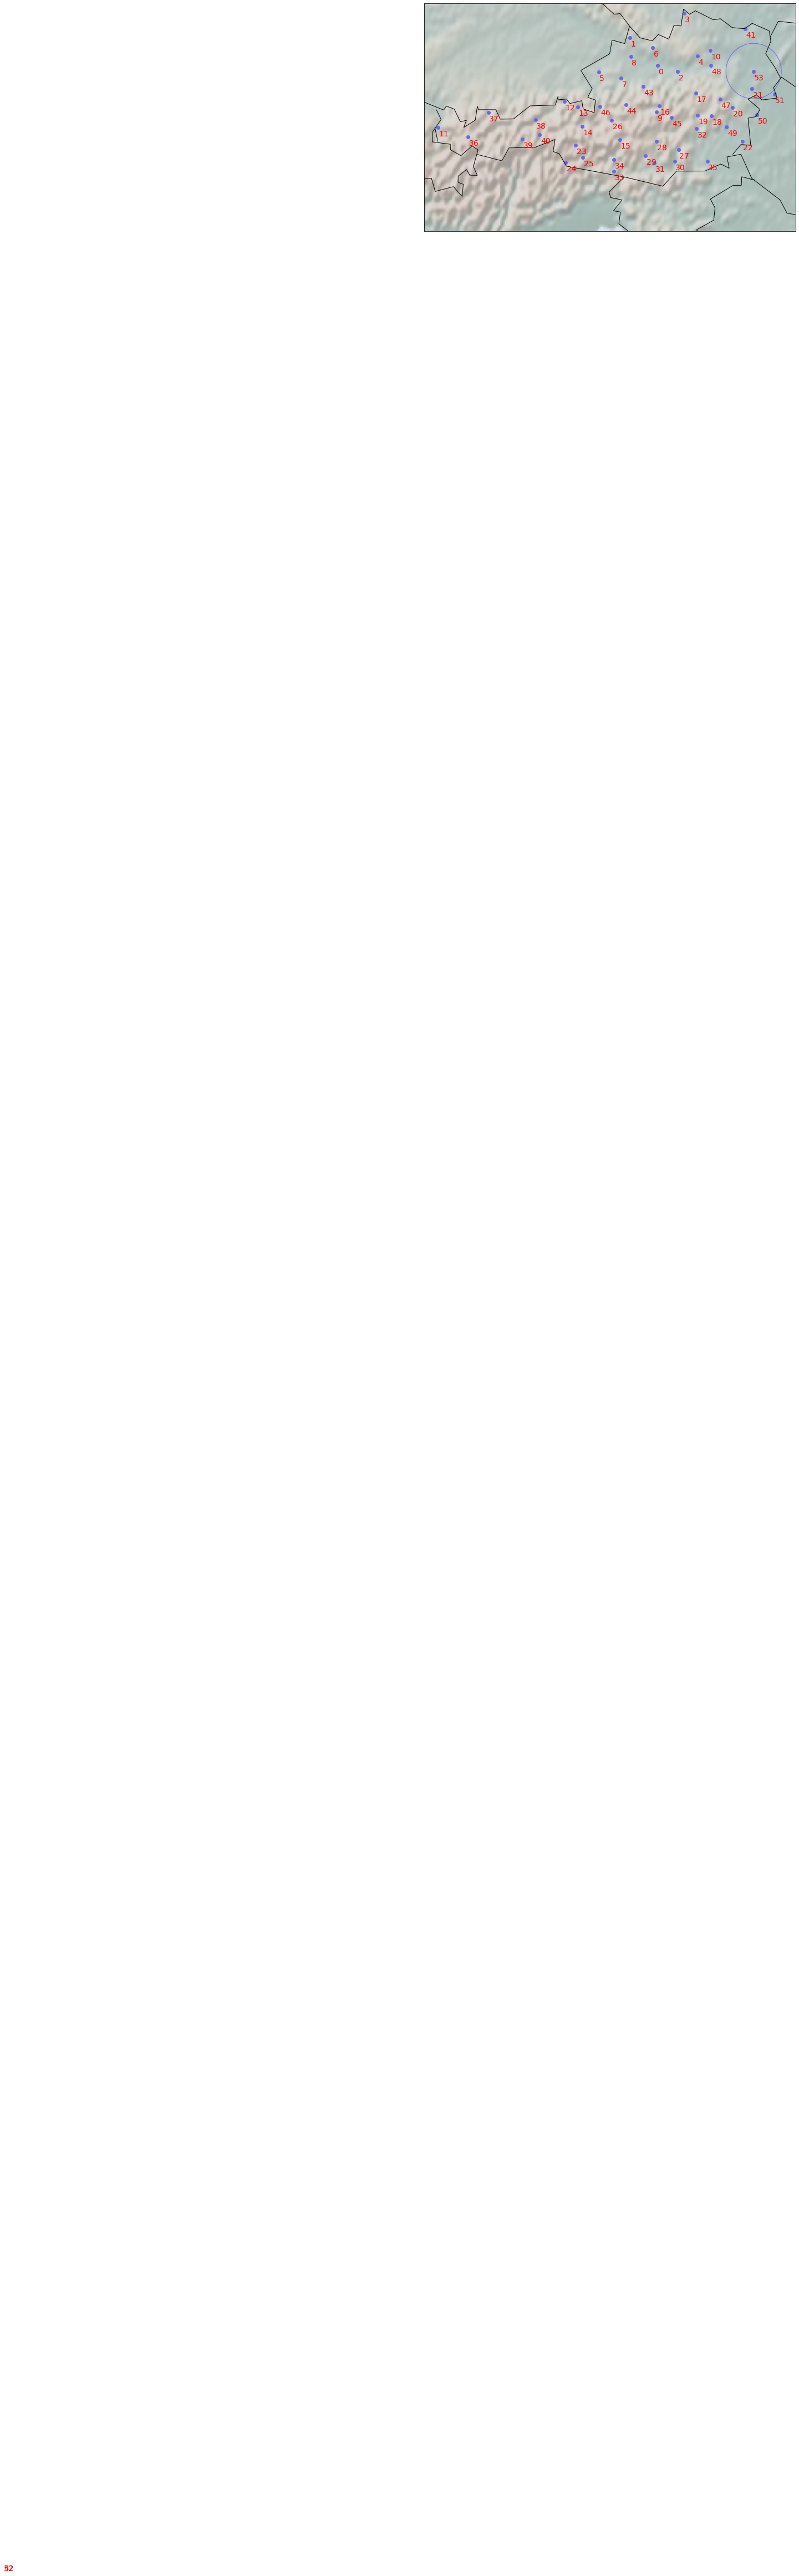

In [ ]:
# Plot stations locations on map

fig = plt.figure(figsize=(12,12))

x1 = 9.3
x2 = 17.5
y1 = 45.7
y2 = 49.1

m = Basemap(resolution='l',projection='merc',\
    llcrnrlat=y1,urcrnrlat=y2,llcrnrlon=x1,\
    urcrnrlon=x2,lat_ts=(x1+x2)/2)

m.drawcountries(linewidth=1)

m.shadedrelief()

m.fillcontinents(color='lightgray',alpha=0.5)

x,y = m(16.5755, 48.1126)
m.scatter(x,y,10000, edgecolor = 'b', color = 'none')


for i in range(len(keys_list)) :

    x,y = m(lon_list[i], lat_list[i])
    
    m.scatter(x,y, c = 'b')
    
    plt.text(x+2000,y-20000,str(i),color='red',size=14);
    

#plt.show()

In [ ]:
# Index of stations close to Vienna Airport

interest_list = [4,10,20,21,41,48,50,51]

In [ ]:
months_list = [0, 13104, 39456, 65664, 92016, 118224, 144576, 170784, 197136, 223488, 249840, 263088]

winter_vis = []

for i in range(0, 11, 2) :
  
  winter_vis = winter_vis + (vis[months_list[i]:months_list[i+1]]).tolist()

winter_vis = np.array(winter_vis)

print(winter_vis.shape)

(131328, 54)


In [ ]:
# Change to winter only
TOTAL = 131328
vis = winter_vis

In [ ]:
print(vis.shape)

(131328, 54)


In [ ]:
# winter_missing = []

# for i in range(54) :

#   winter_missing.append(np.count_nonzero(np.isnan(vis[:,i])))
  
# print(winter_missing)


In [ ]:
[] + [2,3]

[2, 3]

In [ ]:
# # Times data is missing for all stations

# count = 0


# for i in range(TOTAL) :

#     temp_list = [vis[i,stn] for stn in range(54)]

#     if np.isnan(temp_list).all() == True :

#       print(i)

#       count = count + 1

# print(count)

In [ ]:
# closest_list = []

# for i in range(54) :

#   distance_list = []

#   for j in range(54) :

#     latdis = (lat_list[i] - lat_list[j])
#     londis = (lon_list[i] - lon_list[j])

#     distance = (latdis)**2 + (londis)**2

#     distance_list.append(distance)

#   closest_list.append(np.argsort(distance_list).tolist())


# print(closest_list)

4


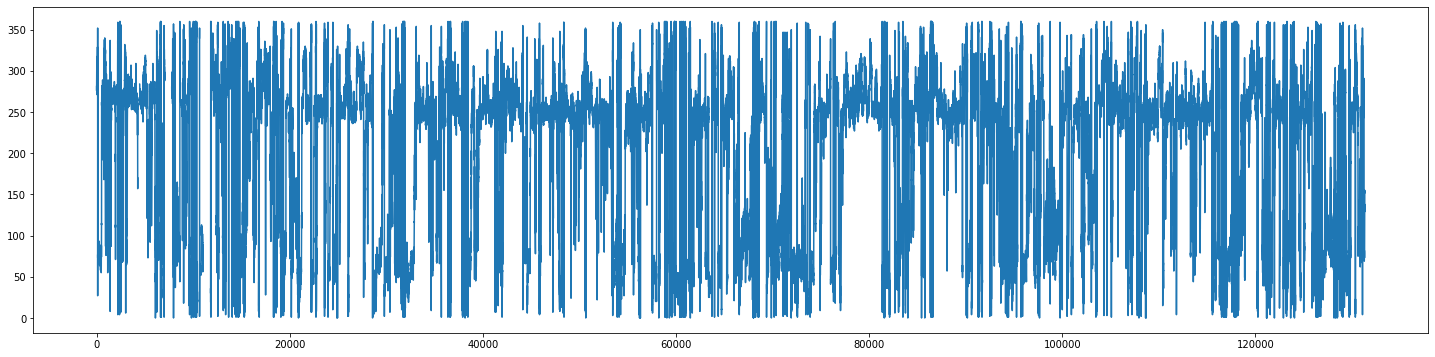

10


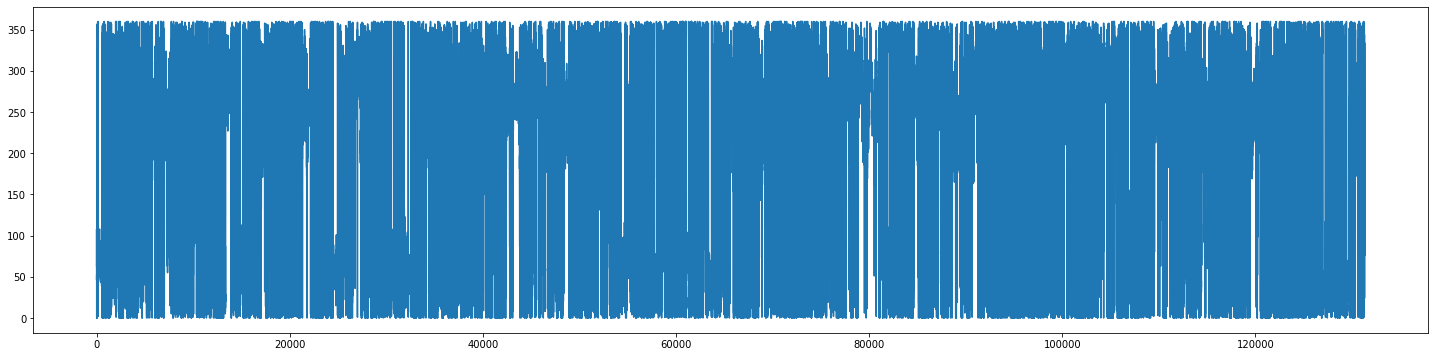

20


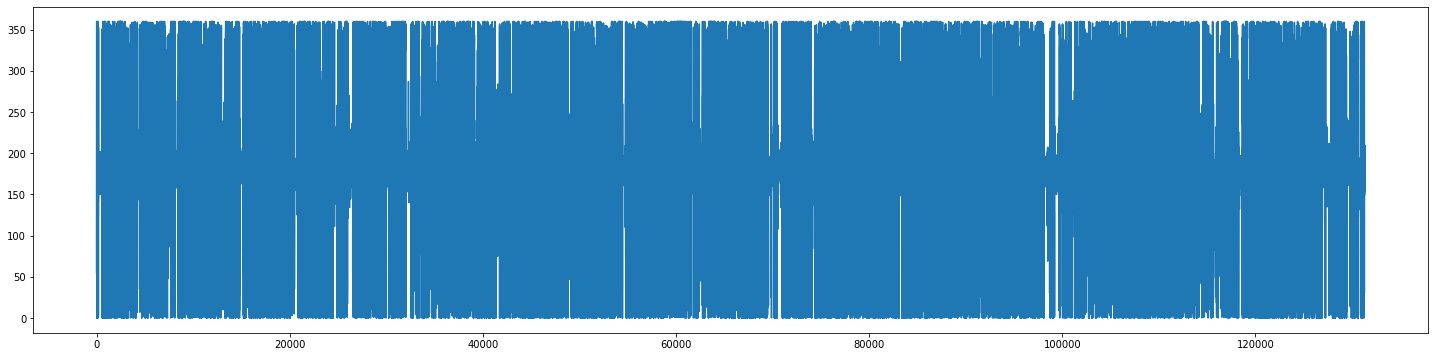

21


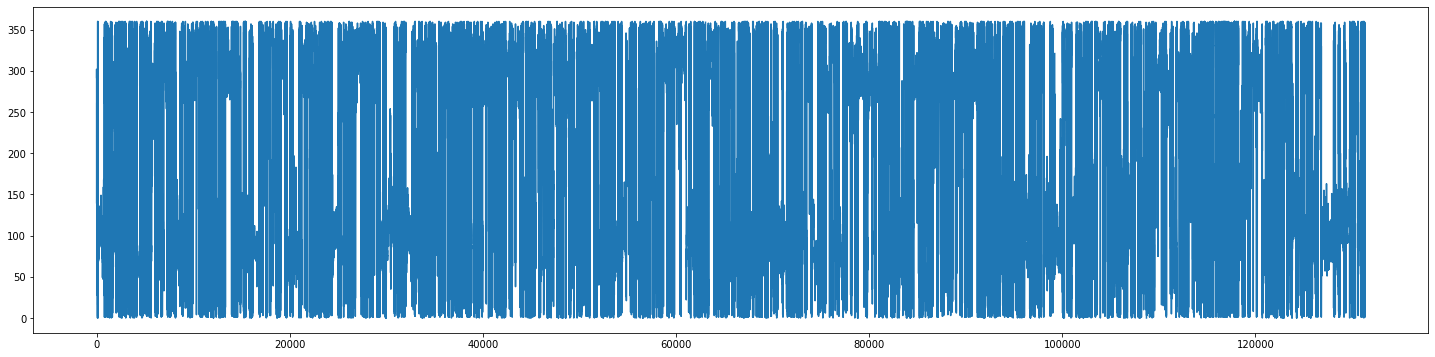

41


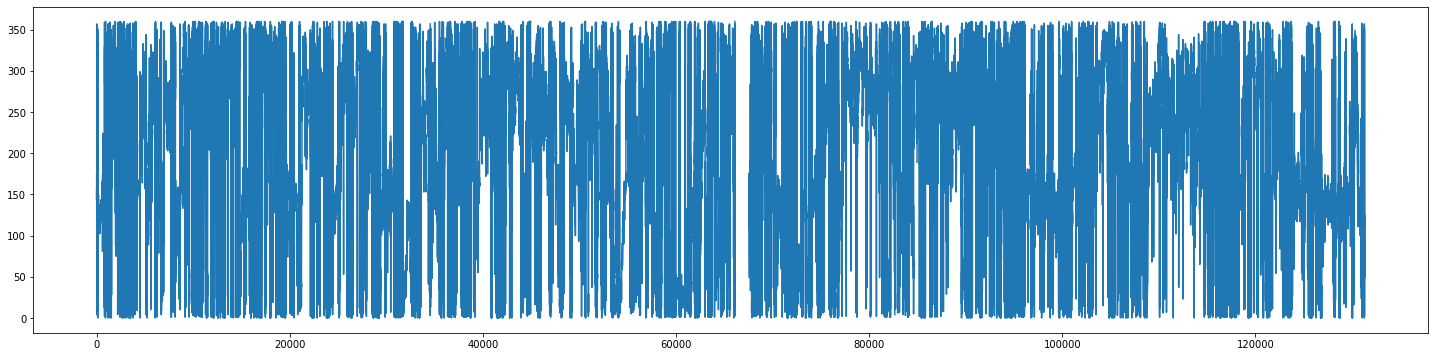

48


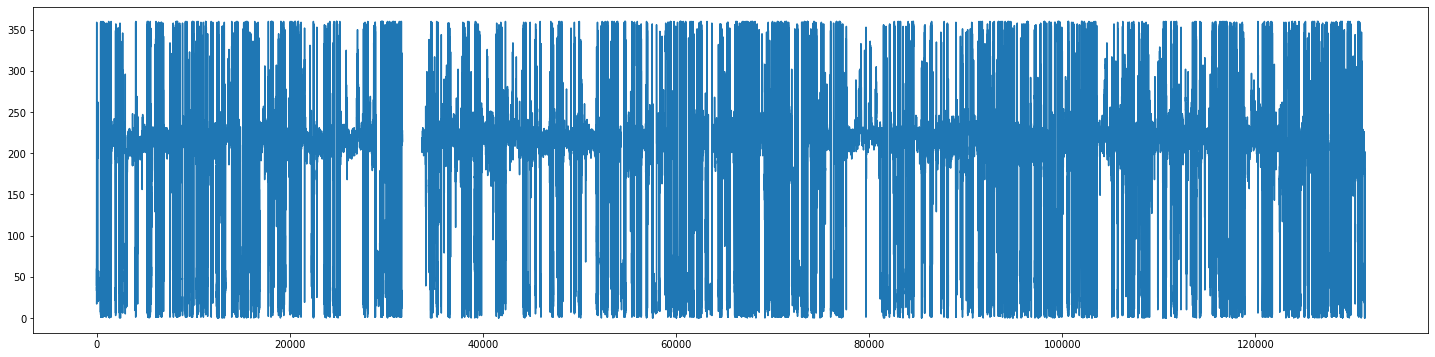

50


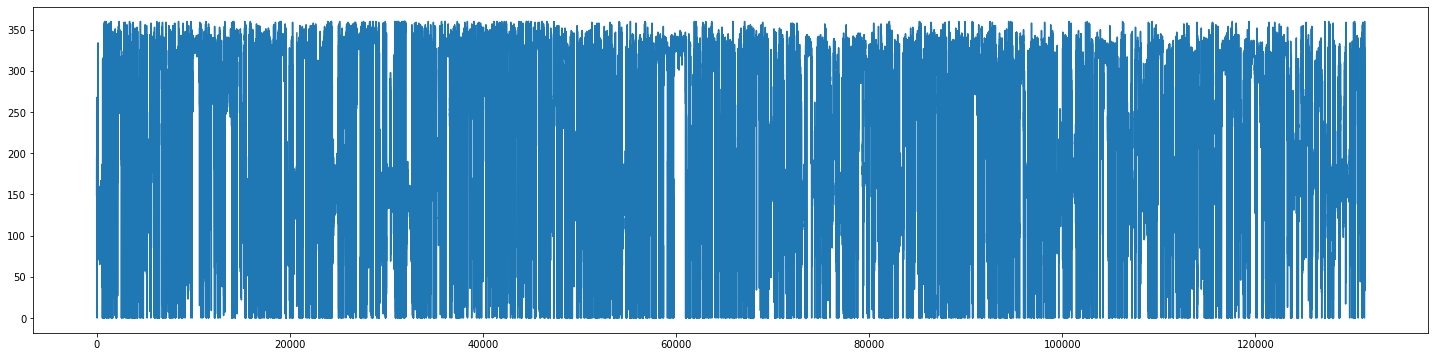

51


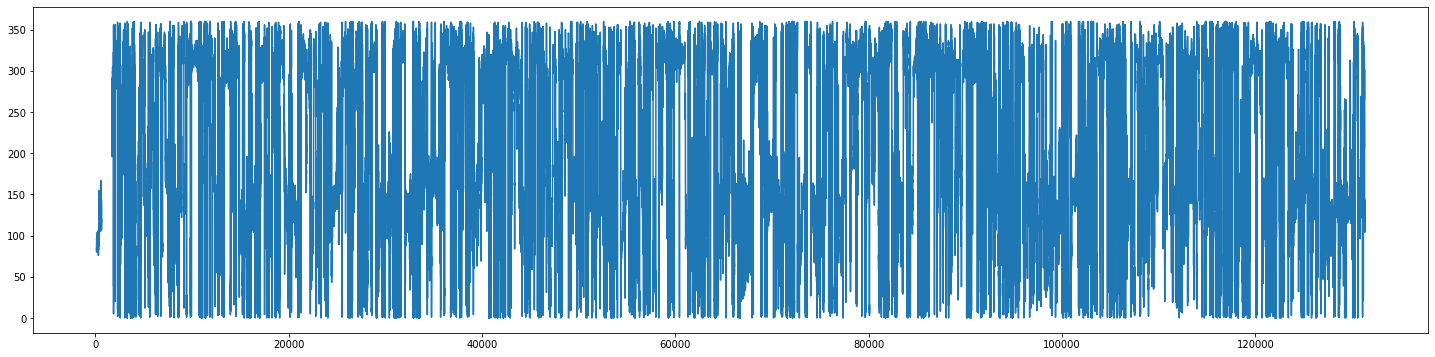

In [ ]:
for stn in interest_list :

  print(stn)
  plt.figure(figsize=(25, 6))
  plt.plot(vis[:,stn])
  plt.show()



In [ ]:
#months_list = [0, 13104, 39456, 65664, 92016, 118224, 144576, 170784, 197136, 223488, 249840, 263088]

def plot_interesting_data():
  for stn in interest_list :

    print("Station: ", stn)
    print("Number missing:", np.count_nonzero(np.isnan(vis[:,stn])))

    plt.figure(figsize=(25, 6))
    plt.plot(vis[:,stn], color = 'b')
    
    
    for i in range(TOTAL) :

      if np.isnan(vis[i,stn]) == True :

        plt.axvline(x=i,color = 'r',lw = 0.1)
    
    
    #for num in months_list :

      #plt.axvline(x=num, color = 'black', lw = 2)

    plt.show()

Station:  4
Number missing: 2988


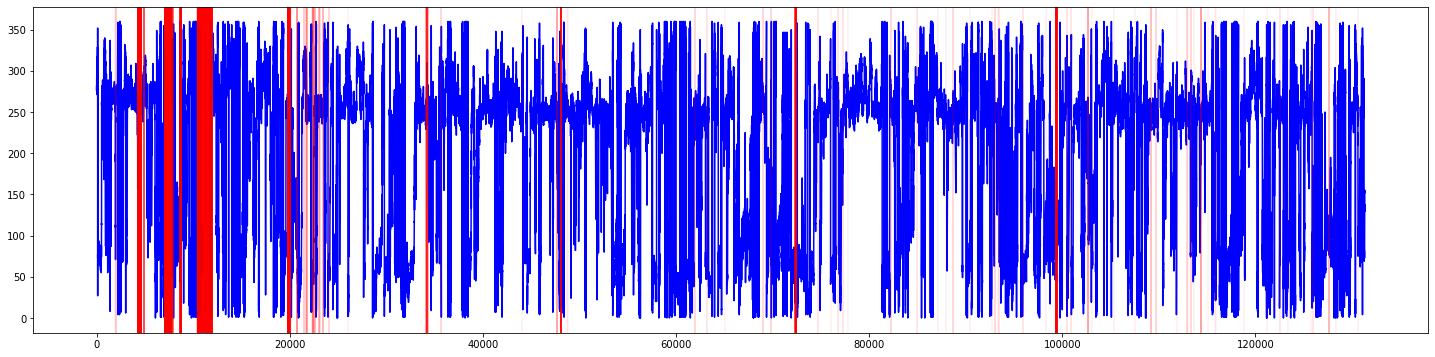

Station:  10
Number missing: 579


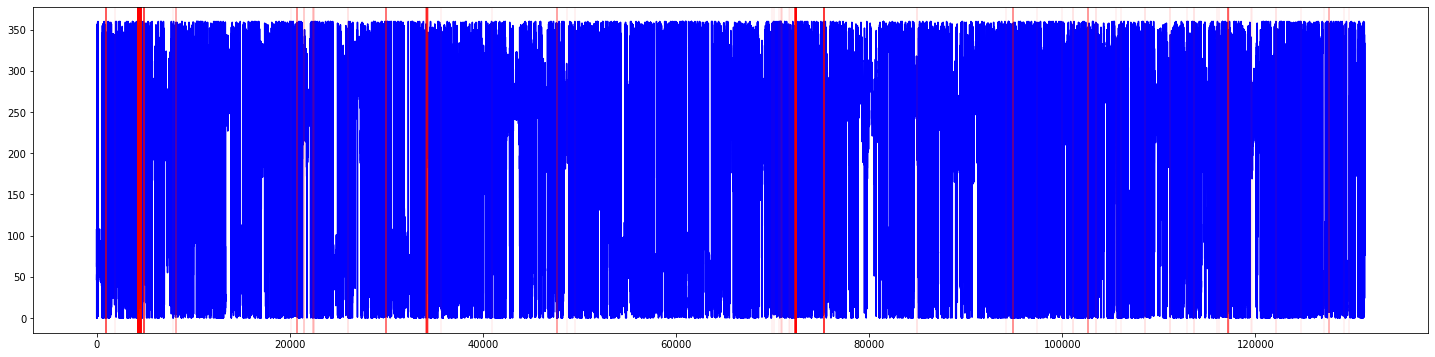

Station:  20
Number missing: 735


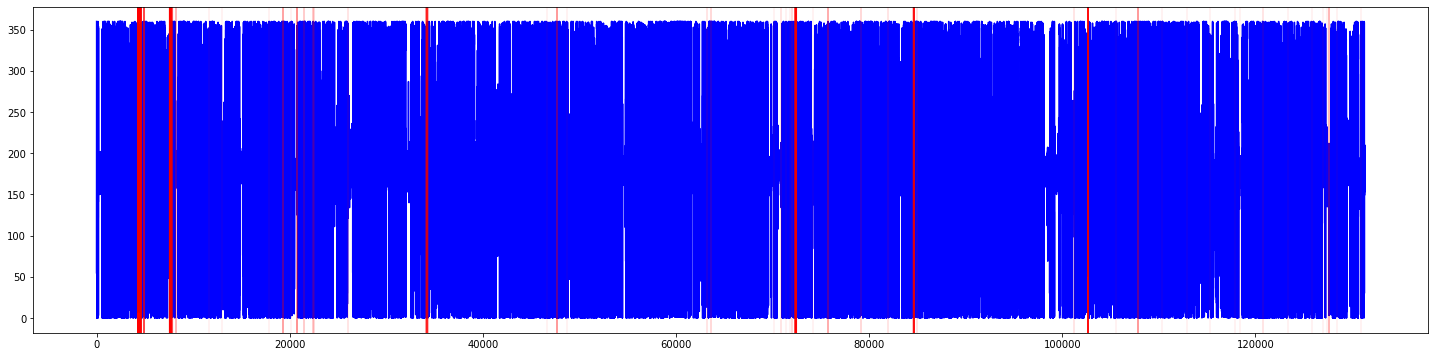

Station:  21
Number missing: 897


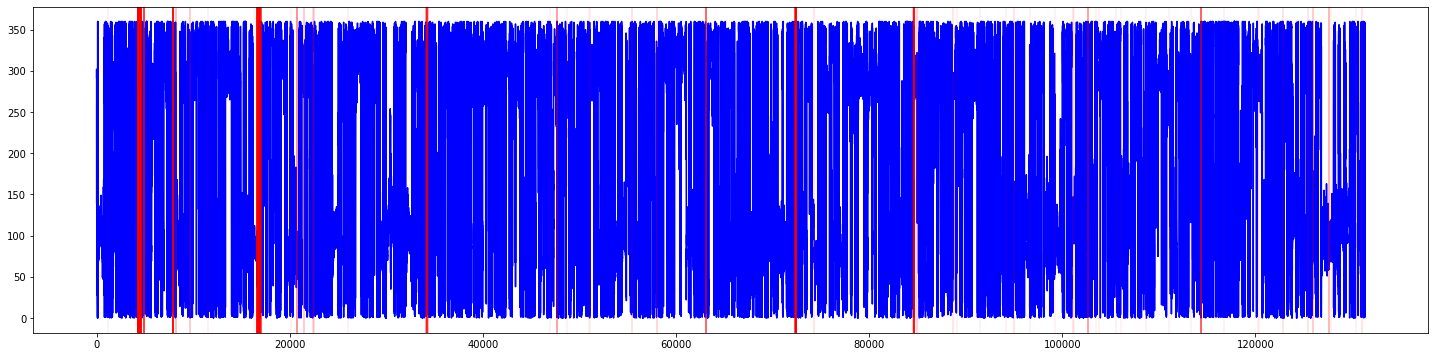

Station:  41
Number missing: 8426


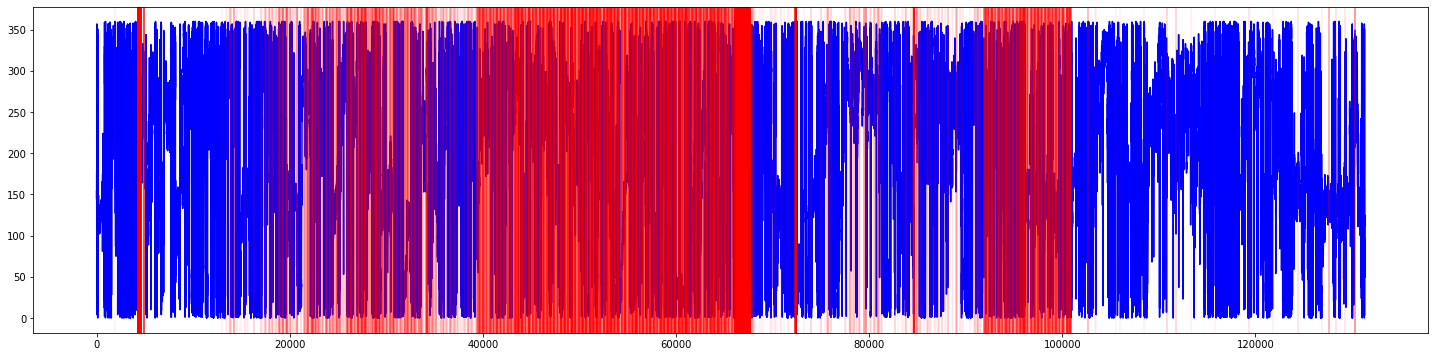

Station:  48
Number missing: 3518


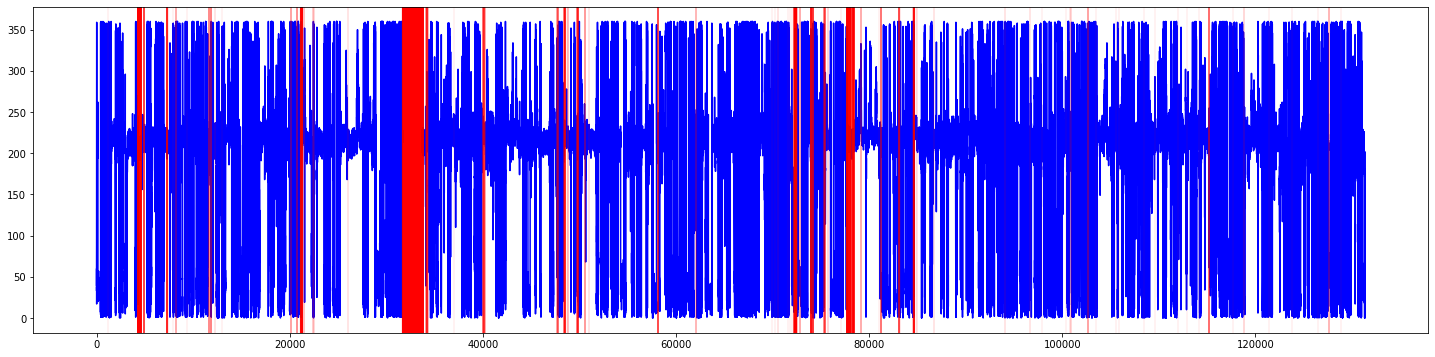

Station:  50
Number missing: 626


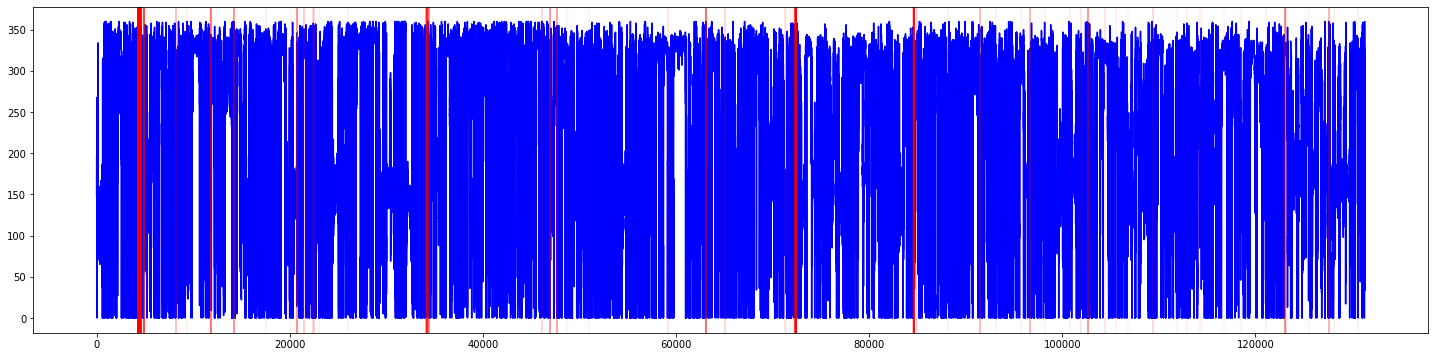

Station:  51
Number missing: 2174


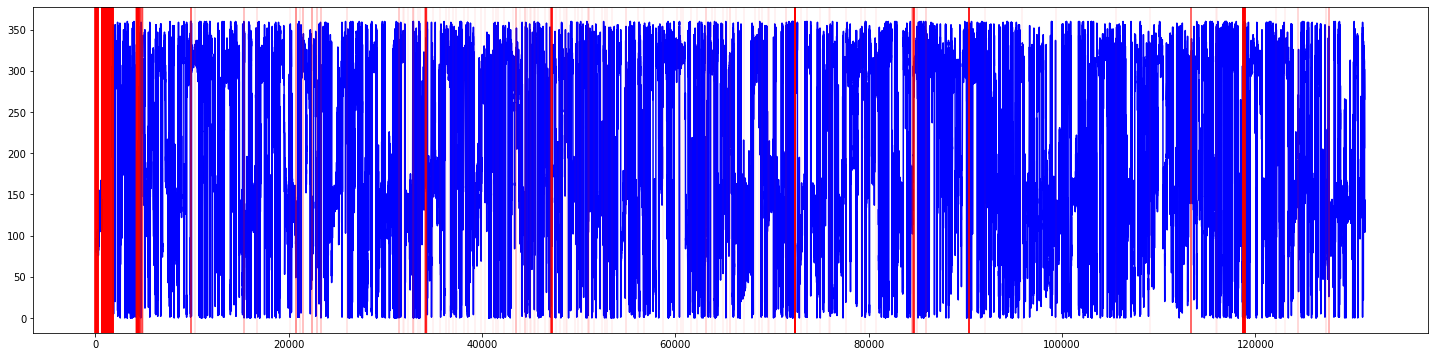

In [ ]:
plot_interesting_data()

In [ ]:
for stn in interest_list :

  for i in range(TOTAL) :

    if np.isnan(vis[i,stn]) == True :

      vis[i,stn] = vis[i,closest_list[stn][1]]

Station:  4
Number missing: 447


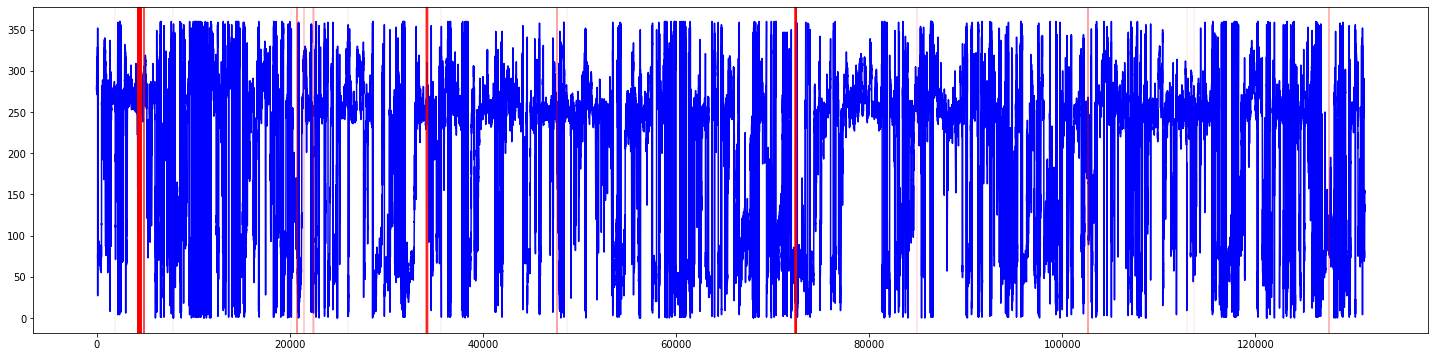

Station:  10
Number missing: 469


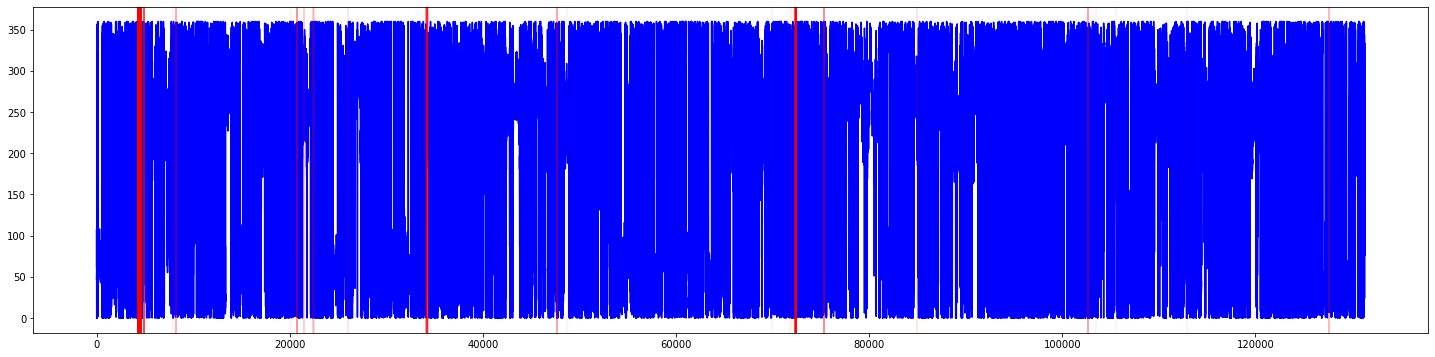

Station:  20
Number missing: 534


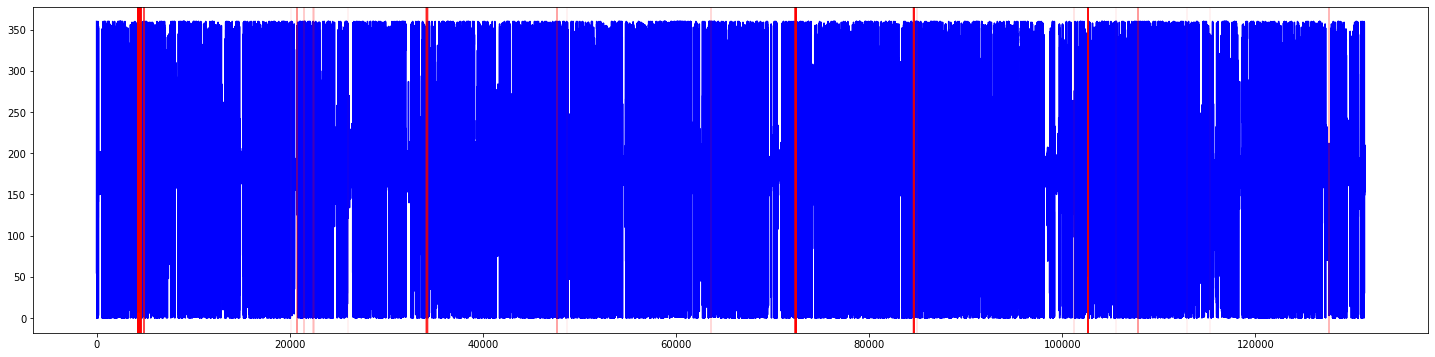

Station:  21
Number missing: 203


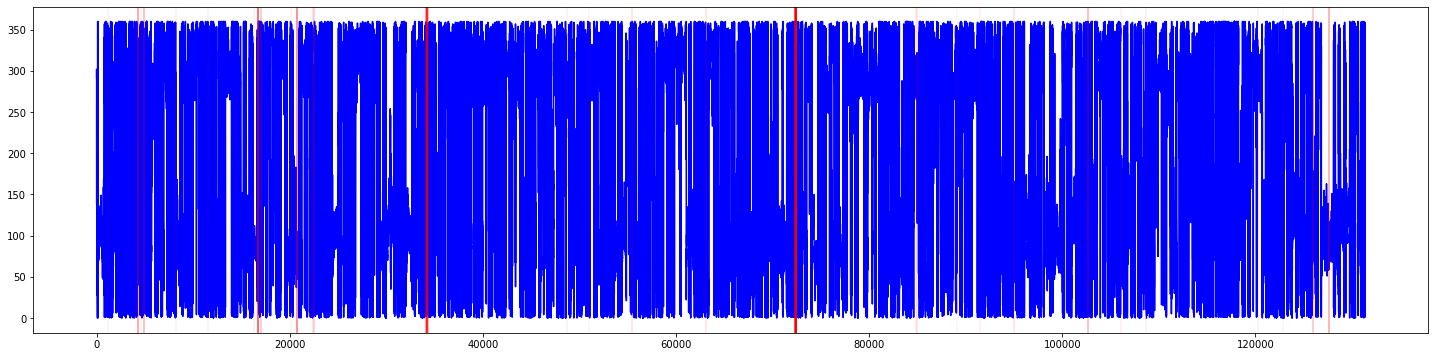

Station:  41
Number missing: 1385


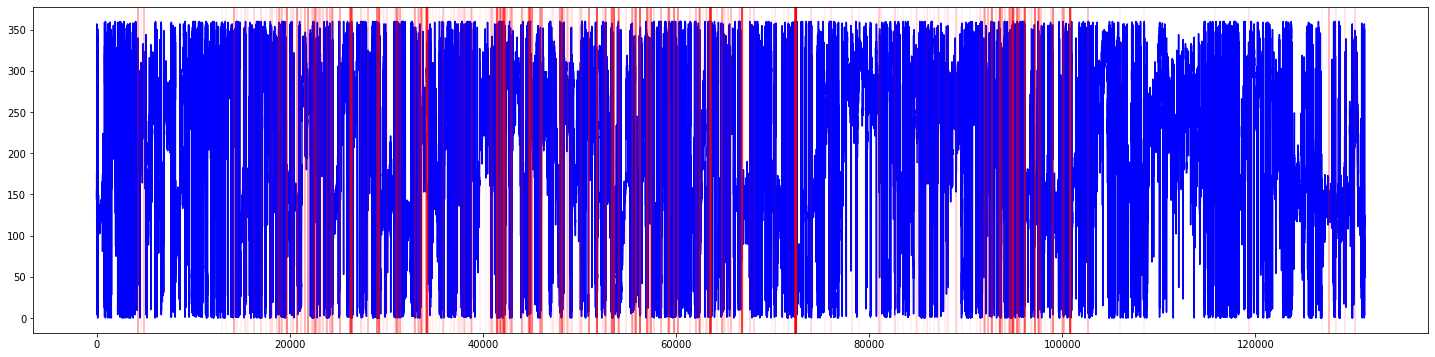

Station:  48
Number missing: 469


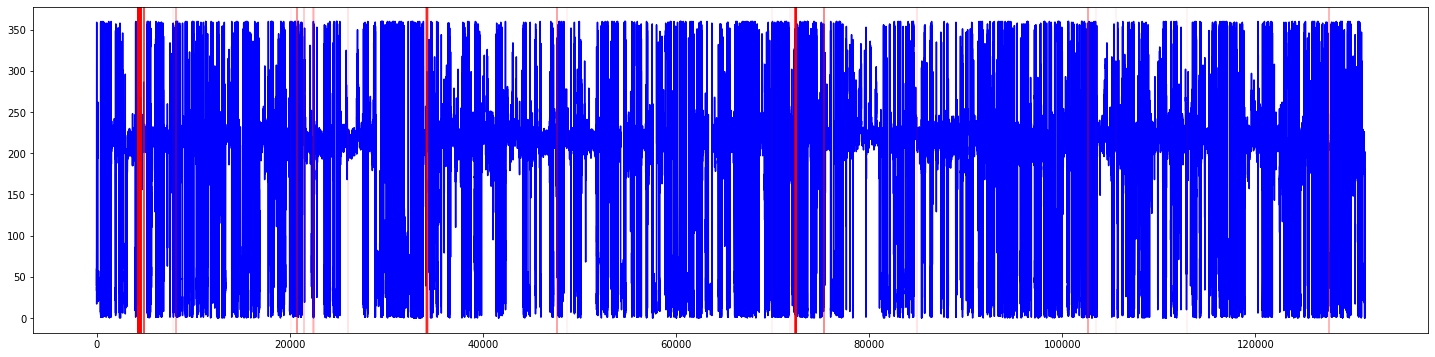

Station:  50
Number missing: 168


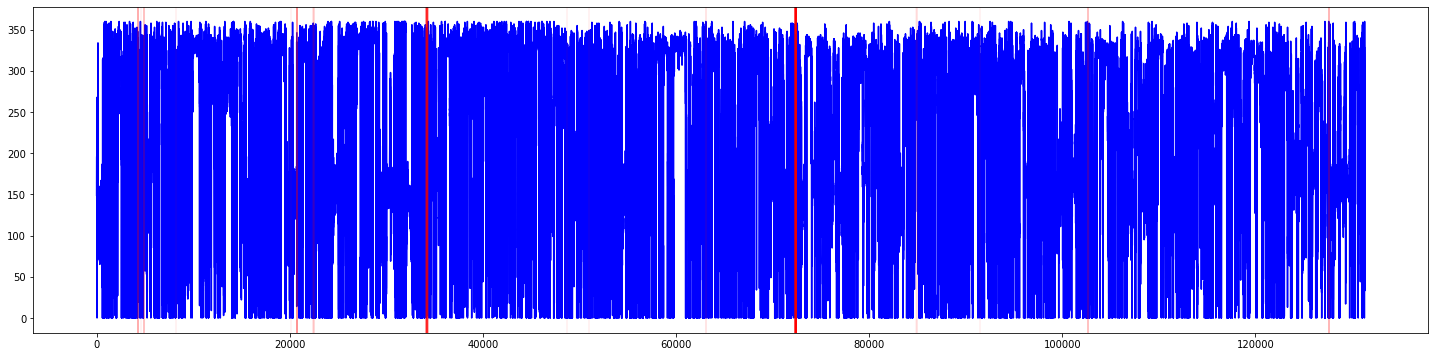

Station:  51
Number missing: 159


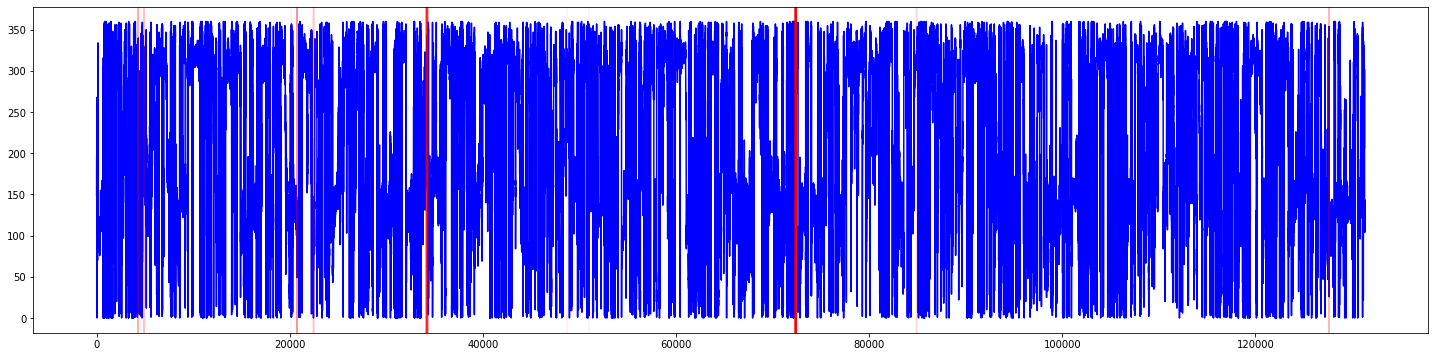

In [ ]:
plot_interesting_data()

In [ ]:
for stn in interest_list :

  series = pd.Series(vis[:,stn])
  temp = series.interpolate()
  temp_arr = temp.to_numpy()
  vis[:,stn] = temp_arr

Station:  4
Number missing: 0


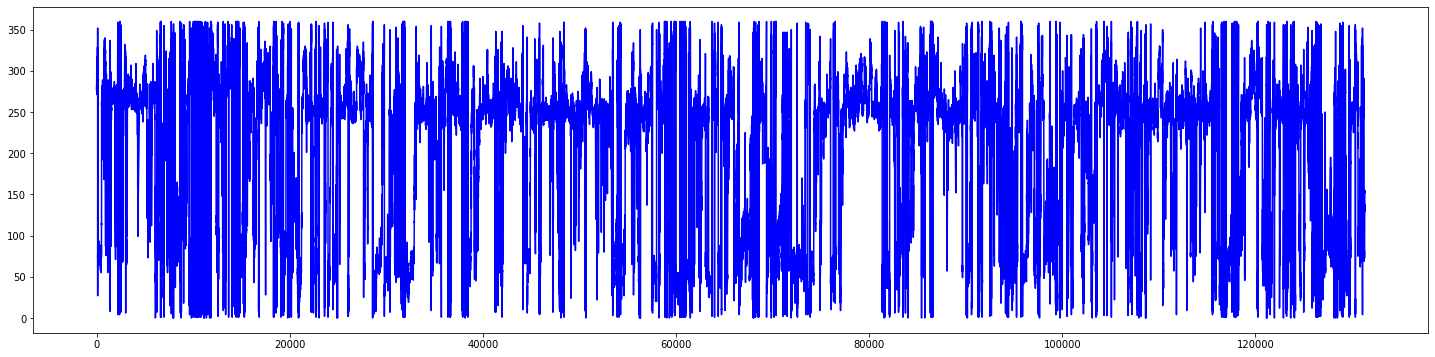

Station:  10
Number missing: 0


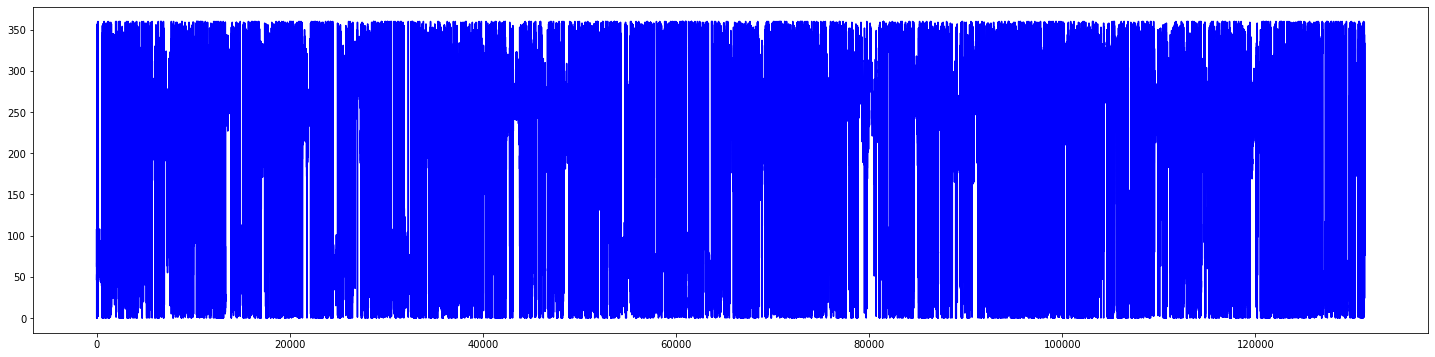

Station:  20
Number missing: 0


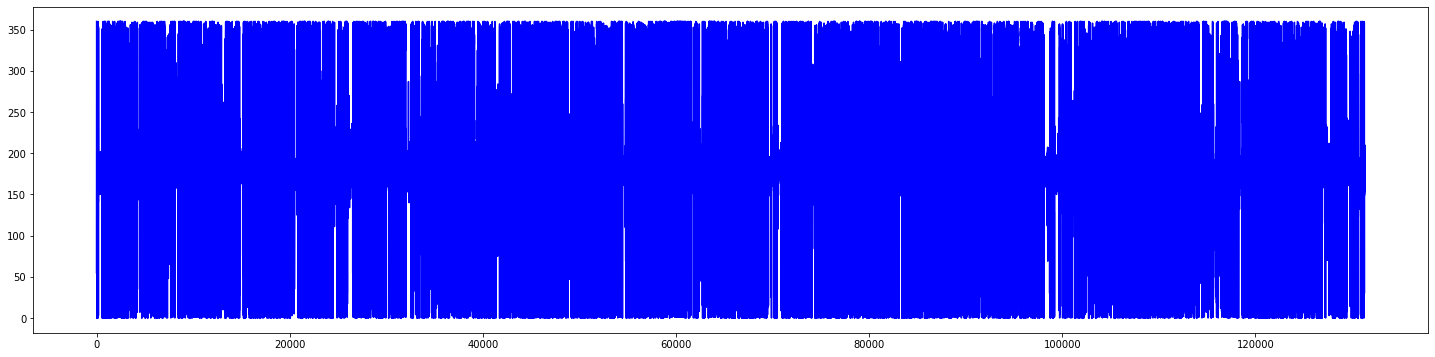

Station:  21
Number missing: 0


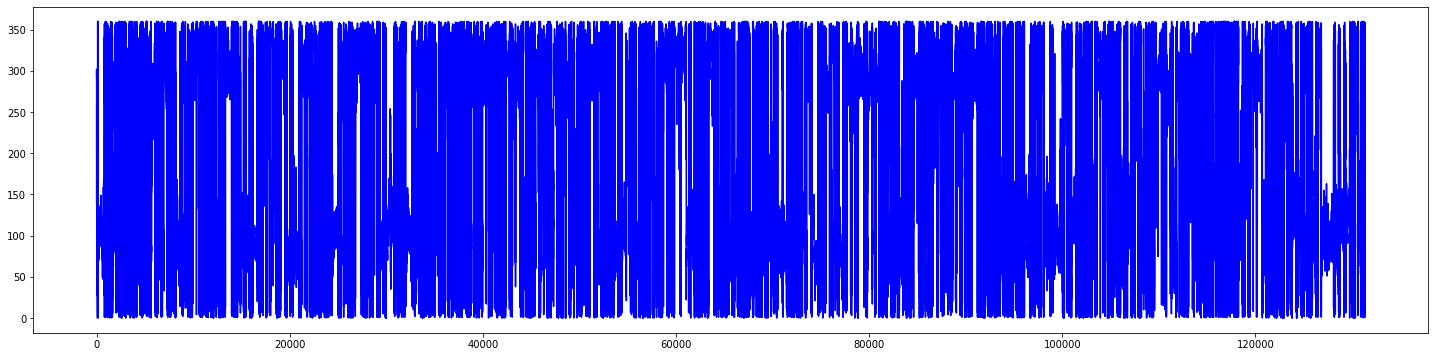

Station:  41
Number missing: 0


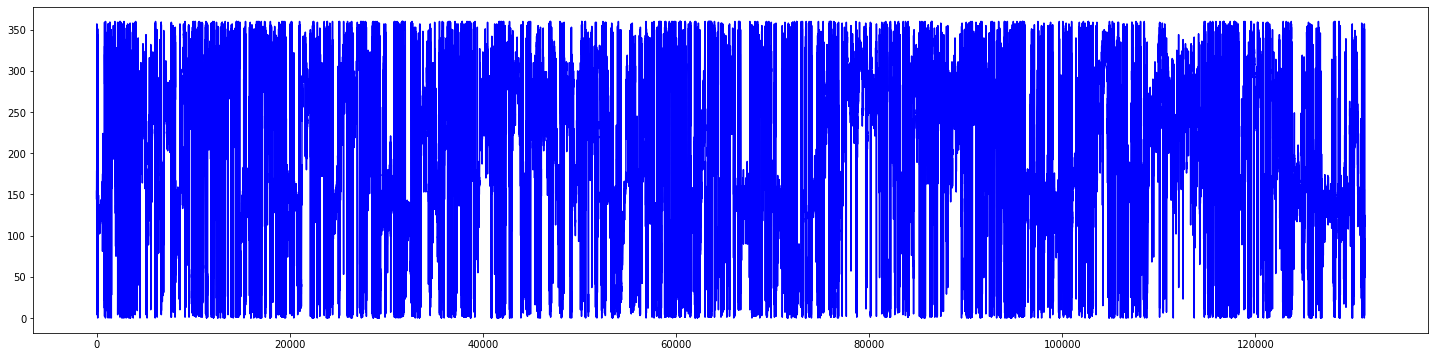

Station:  48
Number missing: 0


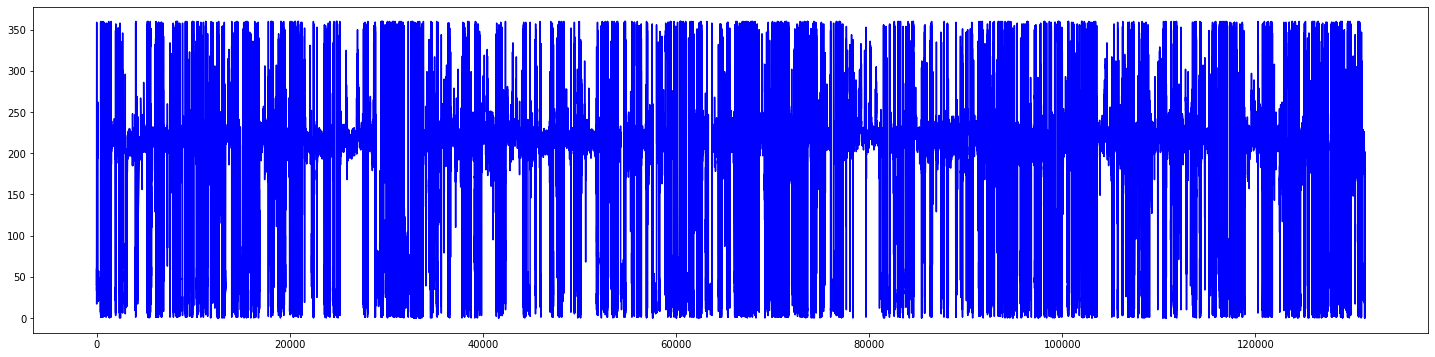

Station:  50
Number missing: 0


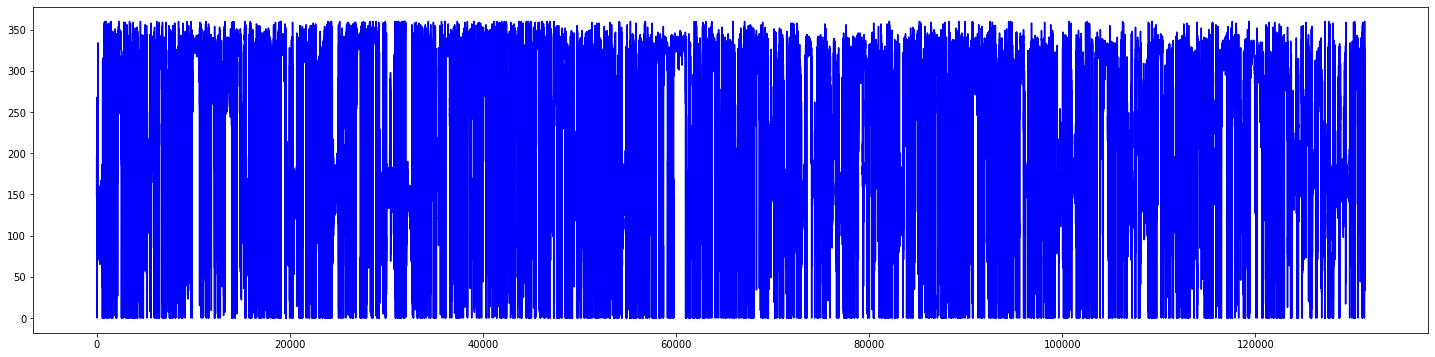

Station:  51
Number missing: 0


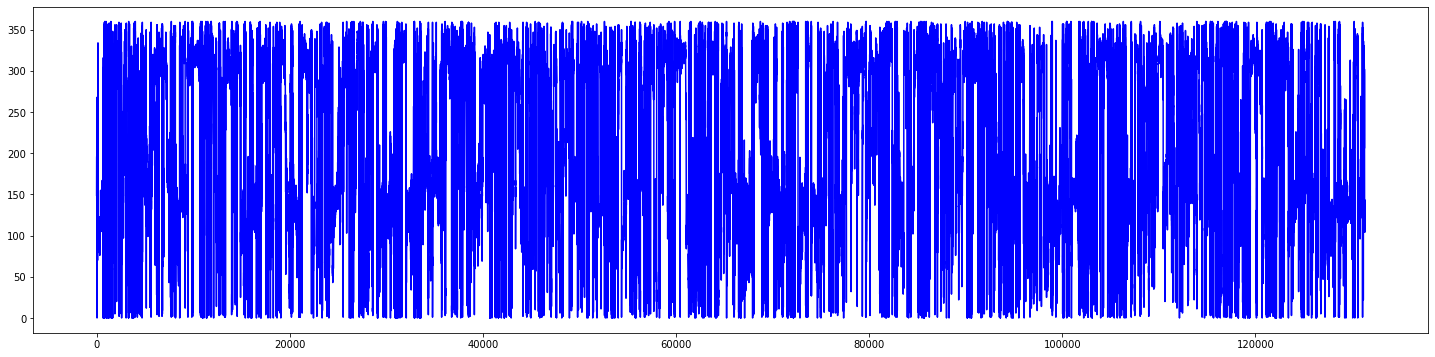

In [ ]:
plot_interesting_data()

In [ ]:
print(np.count_nonzero(np.isnan(vis[:,48])))

0


In [ ]:
np.save('/content/gdrive/MyDrive/Colab Notebooks/Vienna54Stations/wd_54_winter_mod.npy', vis)